In [3]:
import os
import json
from perception_layer.multi_attribute_classifire.clip_based_data_generation.dataset_generation import CLIPPseudoLabeler, apply_category_prior
import random

# Initialize the labeler (run your class cell first)
labeler = CLIPPseudoLabeler()

def visualize_prediction(img_path, ann, labeler):
    img = Image.open(img_path).convert("RGB")
    x, y, w, h = ann["bbox"]
    crop = img.crop((x, y, x + w, y + h))

    # Get labels
    labels = labeler.label(crop)

    # Apply priors (simulating your build_dataset logic)
    cat_id = ann["category_id"]
    weather_final = apply_category_prior(labels["weather"], cat_id, "weather")
    formality_final = apply_category_prior(labels["formality"], cat_id, "formality")

    # Display
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    ax[0].imshow(crop)
    ax[0].set_title(f"Category ID: {cat_id}")
    ax[0].axis('off')

    # Textual readout
    stats = (
        f"RAW SCORES:\n"
        f"Weather: {labels['weather']:.2f}\n"
        f"Formality: {labels['formality']:.2f}\n\n"
        f"AFTER PRIORS:\n"
        f"Weather: {weather_final:.2f}\n"
        f"Formality: {formality_final:.2f}\n\n"
        f"DISTRIBUTIONS:\n"
        f"Fit: {[f'{v:.2f}' for v in labels['fit'].tolist()]}\n"
        f"Style: {[f'{v:.2f}' for v in labels['style'].tolist()]}"
    )
    ax[1].text(0.1, 0.5, stats, fontsize=12, family='monospace', va='center')
    ax[1].axis('off')
    plt.show()

Initializing CLIP on mps...


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

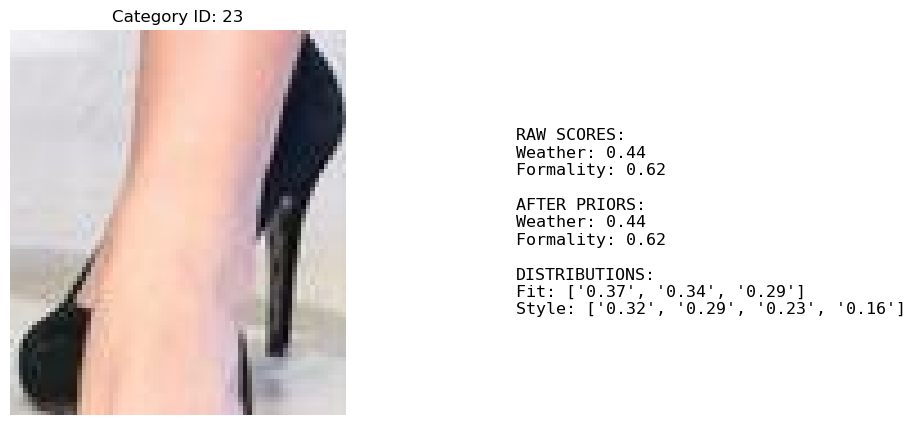

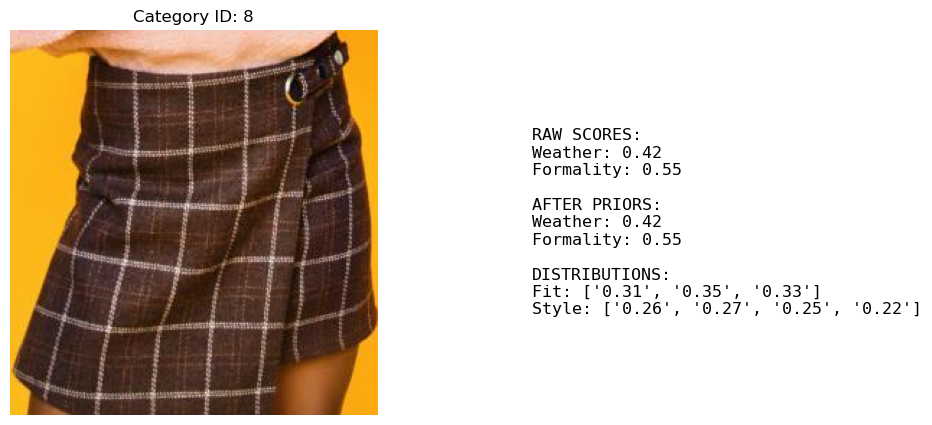

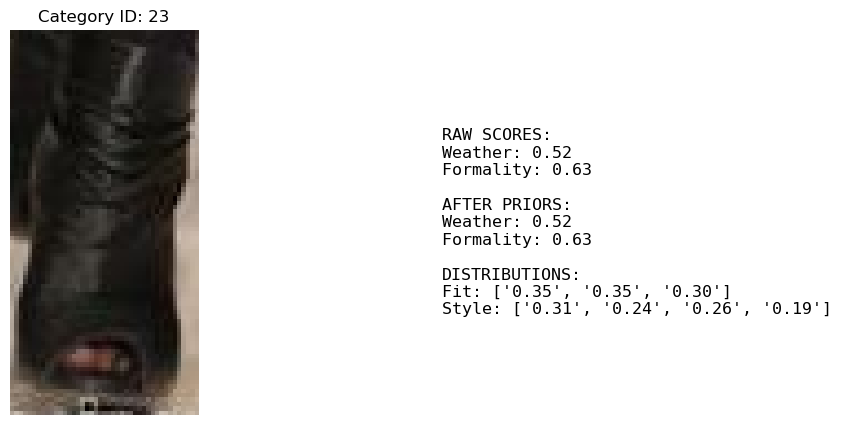

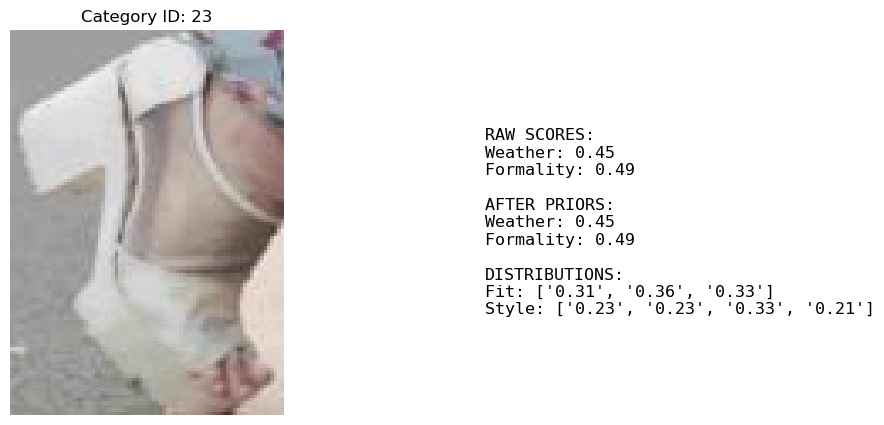

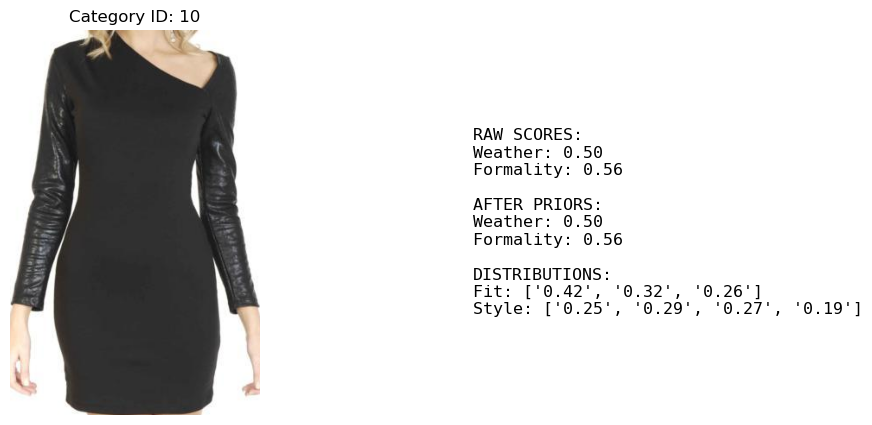

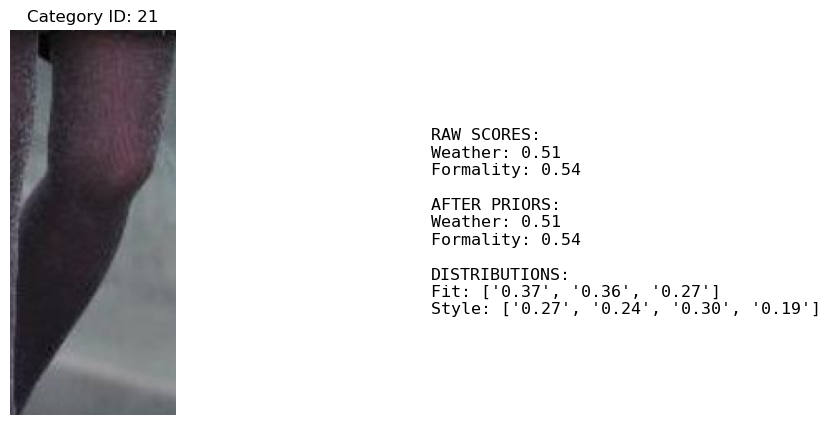

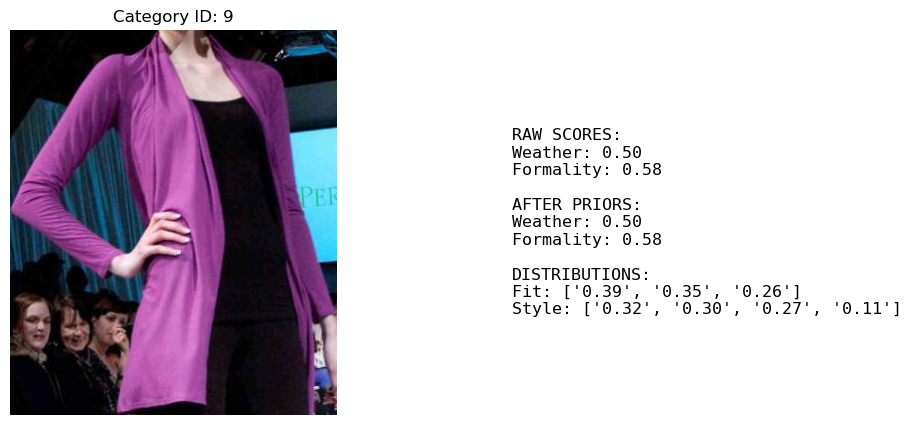

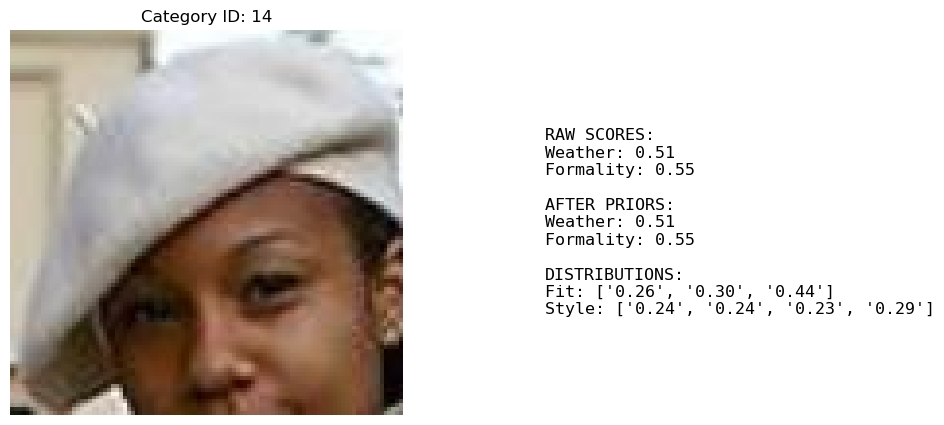

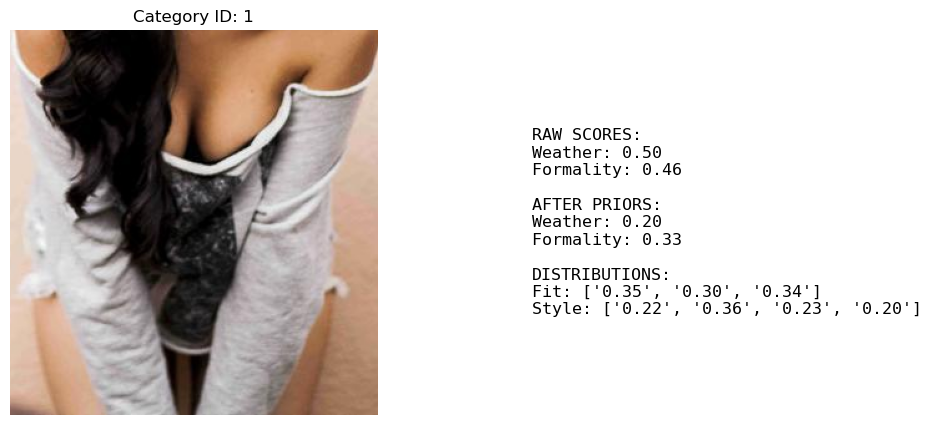

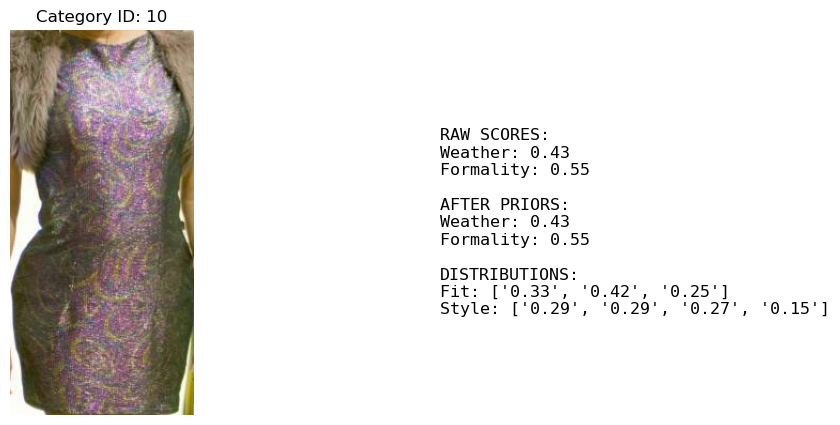

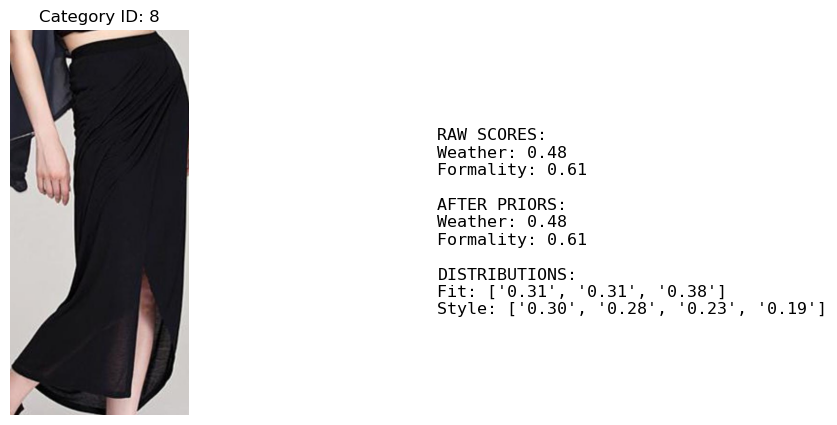

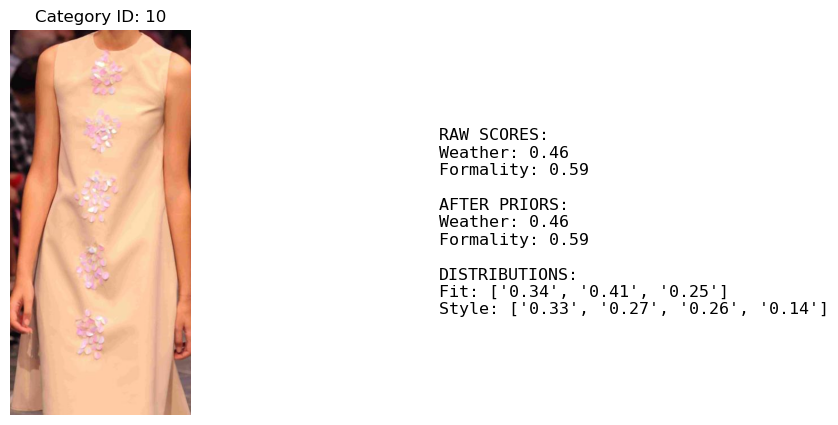

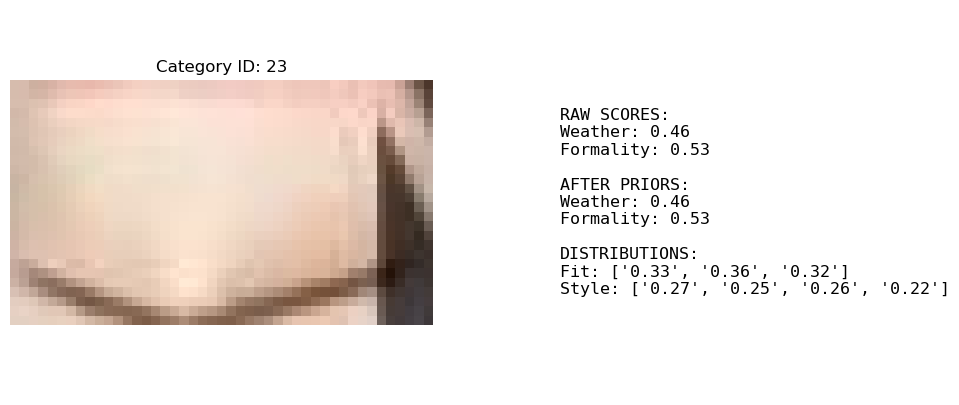

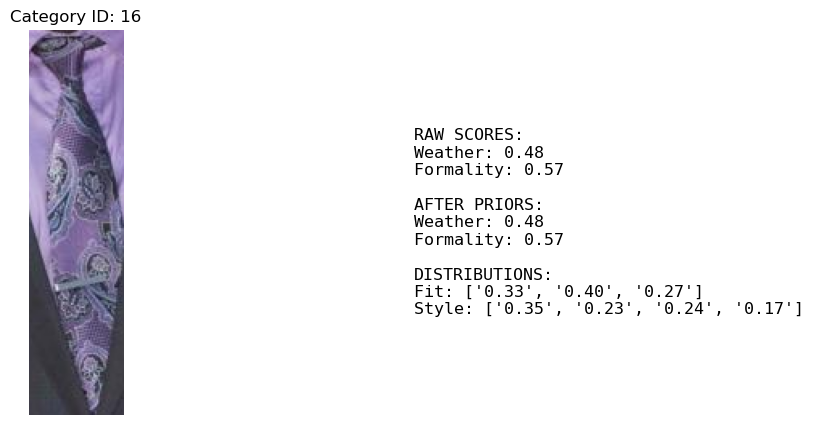

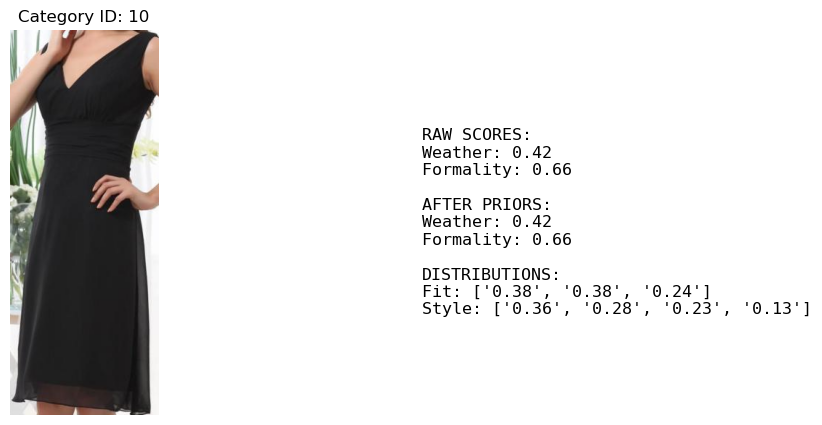

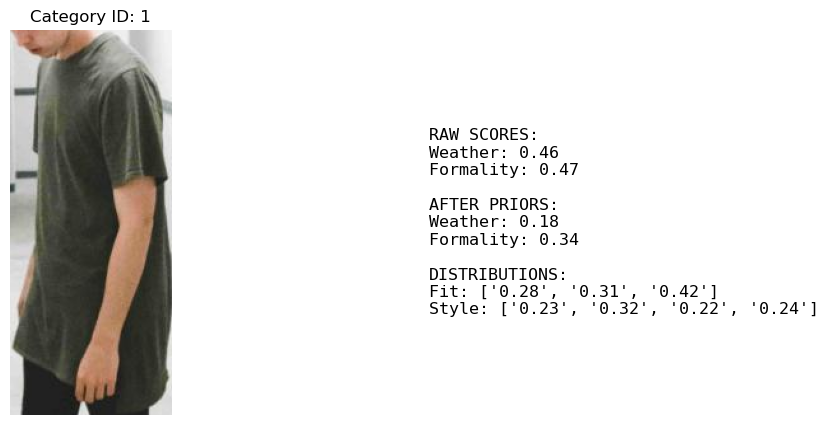

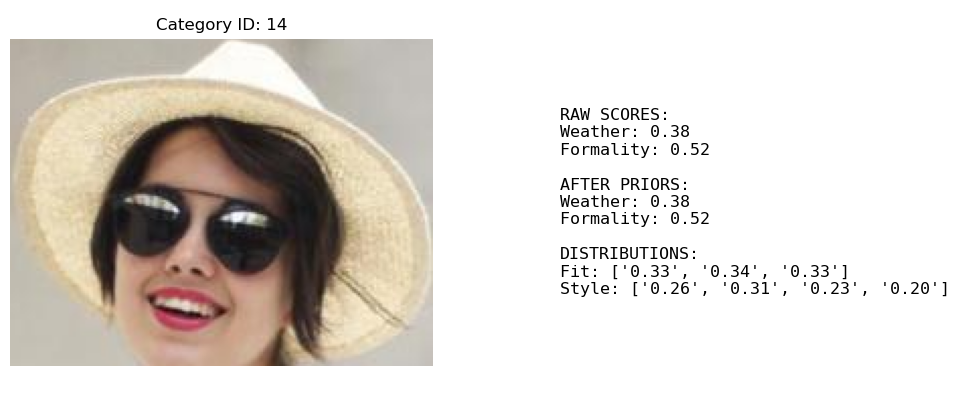

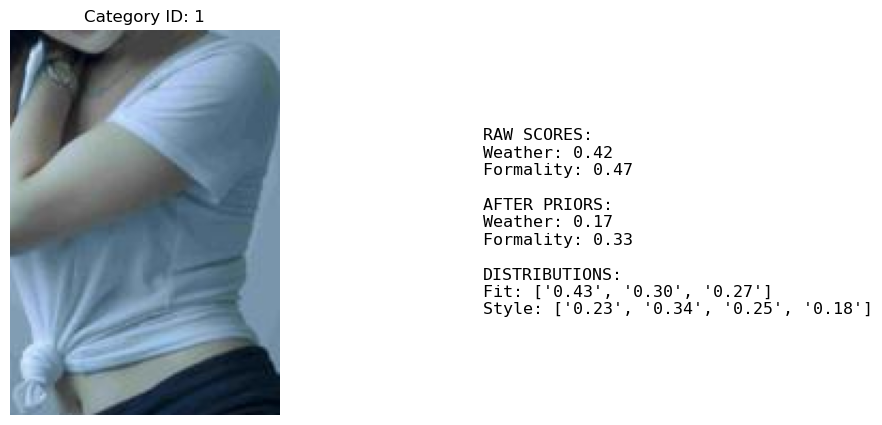

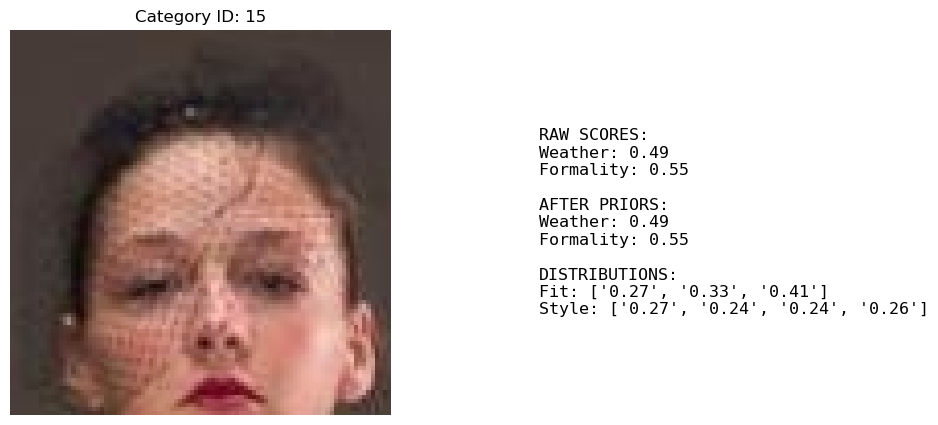

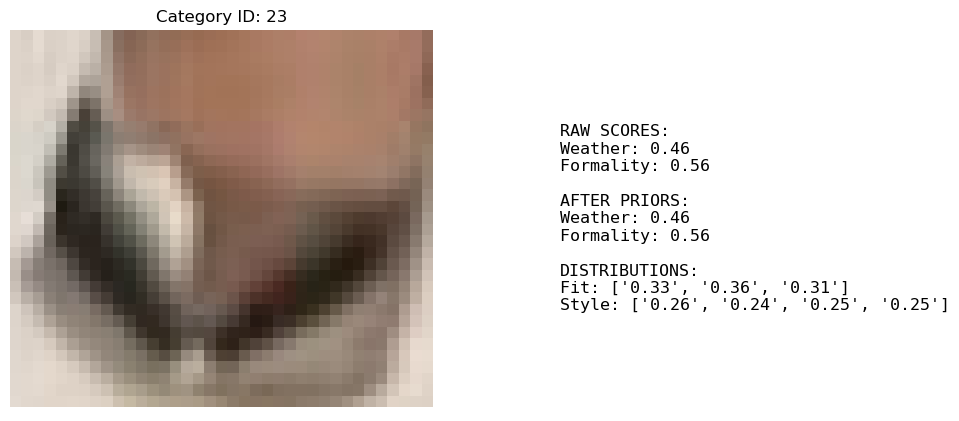

In [4]:
# Test on a few random samples
with open('../../data/fashionpedia_coco/train/_annotations.coco.json') as f:
    coco = json.load(f)

# Pick 3 random samples to inspect
test_samples = random.sample(coco['annotations'], 20)
for ann in test_samples:
    img_file = next(i['file_name'] for i in coco['images'] if i['id'] == ann['image_id'])
    img_path = os.path.join('../../data/fashionpedia_coco/train', img_file)
    visualize_prediction(img_path, ann, labeler)

In [ ]:

import random

def show_random_coco_sample(img_dir, ann_file):
    with open(ann_file) as f:
        coco = json.load(f)

    # Map category IDs to names for labeling
    cat_id_to_name = {cat['id']: cat['name'] for cat in coco['categories']}

    # Pick a random image that actually has annotations
    annotated_img_ids = list(set(ann['image_id'] for ann in coco['annotations']))
    img_id = random.choice(annotated_img_ids)

    # Get image info and its annotations
    img_info = next(img for img in coco['images'] if img['id'] == img_id)
    img_anns = [ann for ann in coco['annotations'] if ann['image_id'] == img_id]

    # Load image
    img_path = os.path.join(img_dir, img_info['file_name'])
    img = Image.open(img_path)

    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(img)

    # Draw boxes
    for ann in img_anns:
        x, y, w, h = ann['bbox']
        cat_name = cat_id_to_name.get(ann['category_id'], "Unknown")

        # Create a Rectangle patch
        rect = patches.Rectangle((x, y-5), w, h, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)

        # Add label text
        plt.text(x, y, cat_name, color='white', fontsize=10,
                 bbox=dict(facecolor='red', alpha=0.5))

    plt.title(f"Image ID: {img_id} | {img_info['file_name']}")
    plt.axis('off')
    plt.show()

# Usage:
show_random_coco_sample('../../data/fashionpedia_coco/train', '../../data/fashionpedia_coco/train/_annotations.coco.json')

In [ ]:
import json

# Path to your newly generated training annotations
ann_file = '../../data/fashionpedia_coco/train/_annotations.coco.json'

with open(ann_file) as f:
    data = json.load(f)

# Look at the first annotation
first_ann = data['annotations'][0]
print(f"Sample BBox: {first_ann['bbox']}")

In [ ]:
import os
import json
import matplotlib.patches as patches
from datasets import load_dataset


def test_inference_and_verify(limit=5):
    print(f"--- Running Dry Run for {limit} images ---")
    full_ds = load_dataset("detection-datasets/fashionpedia", split="train")

    # Process only the first few samples
    test_samples = full_ds.select(range(limit))

    CLASS_NAMES = ['shirt, blouse', 'top, t-shirt, sweatshirt', 'sweater', 'cardigan', 'jacket', 'vest', 'pants', 'shorts', 'skirt', 'coat', 'dress', 'jumpsuit', 'cape', 'glasses', 'hat', 'headband, head covering, hair accessory', 'tie', 'glove', 'watch', 'belt', 'leg warmer', 'tights, stockings', 'sock', 'shoe', 'bag, wallet', 'scarf', 'umbrella', 'hood', 'collar', 'lapel', 'epaulette', 'sleeve', 'pocket', 'neckline', 'buckle', 'zipper', 'applique', 'bead', 'bow', 'flower', 'fringe', 'ribbon', 'rivet', 'ruffle', 'sequin', 'tassel']

    for idx, sample in enumerate(test_samples):
        img_w, img_h = sample['image'].size
        obj_data = sample['objects']

        fig, ax = plt.subplots(1, figsize=(8, 8))
        ax.imshow(sample['image'])

        print(f"\nImage {idx}: {img_w}x{img_h}")

        for i in range(len(obj_data['category'])):
            bbox = obj_data['bbox'][i]

            # --- YOUR CURRENT LOGIC CHECK ---
            # Fashionpedia (HF) provides [xmin, ymin, xmax, ymax] in absolute pixels.
            xmin = float(bbox[0])
            ymin = float(bbox[1])
            xmax = float(bbox[2])
            ymax = float(bbox[3])

            # COCO Format: [xmin, ymin, width, height]
            w = xmax - xmin
            h = ymax - ymin

            cat_name = CLASS_NAMES[obj_data['category'][i]] if obj_data['category'][i] < len(CLASS_NAMES) else "Unknown"

            # Draw standard Rectangle
            rect = patches.Rectangle((xmin, ymin), w, h, linewidth=2, edgecolor='lime', facecolor='none')
            ax.add_patch(rect)
            plt.text(xmin, ymin - 5, cat_name, color='white', weight='bold', bbox=dict(facecolor='green', alpha=0.5))

            print(f"  - Detected: {cat_name} at [{xmin:.1f}, {ymin:.1f}, {w:.1f}, {h:.1f}]")

        plt.title(f"Test Sample {idx}")
        plt.axis('off')
        plt.show()

test_inference_and_verify()

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]


--- AI Classification Results ---
Formal business attire with structured shoulders : 1.56%
Casual streetwear with a relaxed oversized fit : 39.60%
Sporty athletic wear for the gym : 32.98%
Smart casual clothing for a dinner date : 25.87%


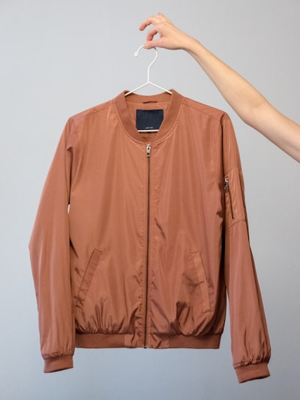

In [1]:

from transformers import CLIPProcessor, CLIPModel
import requests
from io import BytesIO

# 1. Load the Fashion-CLIP model and processor
# This might take a moment to download (~600MB)
model_name = "patrickjohncyh/fashion-clip"
model = CLIPModel.from_pretrained(model_name)
processor = CLIPProcessor.from_pretrained(model_name)

def test_fashion_logic(image_source, categories):
    # Load image from URL or Local Path
    if image_source.startswith('http'):
        response = requests.get(image_source)
        img = Image.open(BytesIO(response.content)).convert("RGB")
    else:
        img = Image.open(image_source).convert("RGB")

    # Prepare inputs: Image + our custom labels
    inputs = processor(
        text=categories,
        images=img,
        return_tensors="pt",
        padding=True
    )

    # Run Inference
    with torch.no_grad():
        outputs = model(**inputs)

    # Calculate probabilities (Softmax)
    logits_per_image = outputs.logits_per_image
    probs = logits_per_image.softmax(dim=1).cpu().numpy()[0]

    # Print Results
    print(f"\n--- AI Classification Results ---")
    for label, prob in zip(categories, probs):
        print(f"{label:30} : {prob*100:.2f}%")

    return img

img_path = "data/my_shirt.jpg"
test_img = "https://images.unsplash.com/photo-1591047139829-d91aecb6caea?auto=format&fit=crop&q=80&w=400" # Example: A Jacket

# Define your "Micro" categories
labels = [
    "Formal business attire with structured shoulders",
    "Casual streetwear with a relaxed oversized fit",
    "Sporty athletic wear for the gym",
    "Smart casual clothing for a dinner date"
]

display_img = test_fashion_logic(test_img, labels)
display_img.resize((300, 400)) # Show the image in cell

In [2]:
# Optional, run once if needed:
# !pip install torch torchvision transformers pillow matplotlib

from pathlib import Path
from typing import Optional

import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
from transformers import CLIPModel, CLIPProcessor


DEFAULT_FASHIONCLIP_MODEL = "patrickjohncyh/fashion-clip"
TAU = 0.05


CATEGORY_PRIORS = {
    4: {"weather": (0.7, 1.0), "formality": (0.3, 0.9)},  # jacket
    1: {"weather": (0.0, 0.4), "formality": (0.1, 0.6)},  # t-shirt
    6: {"weather": (0.3, 0.8), "formality": (0.2, 0.7)},  # pants
    7: {"weather": (0.0, 0.5), "formality": (0.1, 0.5)},  # shorts
}

CATEGORY_PROMPTS = {
    1: "a photo of a t-shirt",
    2: "a photo of a shirt or blouse",
    3: "a photo of a sweater or hoodie",
    4: "a photo of a jacket or coat",
    5: "a photo of a dress",
    6: "a photo of pants or trousers",
    7: "a photo of shorts",
    8: "a photo of a skirt",
    9: "a photo of shoes",
    10: "a photo of a bag or handbag",
}

CATEGORY_NAMES = {
    1: "t-shirt",
    2: "shirt/blouse",
    3: "sweater/hoodie",
    4: "jacket/coat",
    5: "dress",
    6: "pants/trousers",
    7: "shorts",
    8: "skirt",
    9: "shoes",
    10: "bag/handbag",
}

WEATHER_LABELS = [
    "freezing winter weather",
    "mild layered transitional weather",
    "hot sunny summer weather",
]

WEATHER_PROMPTS = [
    "a photo of a fashion garment suitable for freezing winter weather",
    "a photo of a fashion garment suitable for mild layered transitional weather",
    "a photo of a fashion garment suitable for hot sunny summer weather",
]

FORMALITY_LABELS = [
    "formal black tie event",
    "professional business office",
    "smart casual dinner",
    "everyday casual wear",
    "working out at the gym",
]

FORMALITY_PROMPTS = [
    "a photo of a fashion garment suitable for a formal black tie event",
    "a photo of a fashion garment suitable for a professional business office",
    "a photo of a fashion garment suitable for a smart casual dinner",
    "a photo of a fashion garment suitable for everyday casual wear",
    "a photo of a fashion garment suitable for working out at the gym",
]

FIT_LABELS = [
    "tight slim fit",
    "regular standard fit",
    "oversized baggy fit",
]

FIT_PROMPTS = [
    "a photo of a tight slim fit fashion garment",
    "a photo of a regular standard fit fashion garment",
    "a photo of an oversized baggy fit fashion garment",
]

STYLE_LABELS = [
    "formal",
    "casual",
    "sport",
    "streetwear",
]

STYLE_PROMPTS = [
    "a photo of a formal style fashion garment",
    "a photo of a casual style fashion garment",
    "a photo of a sport style fashion garment",
    "a photo of a streetwear style fashion garment",
]

FORMALITY_WEIGHTS = torch.tensor([1.0, 0.8, 0.6, 0.3, 0.0])
WEATHER_WEIGHTS = torch.tensor([1.0, 0.5, 0.0])


def get_device() -> str:
    if torch.cuda.is_available():
        return "cuda"
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    return "cpu"


def apply_category_prior(value: float, cat_id: Optional[int], key: str) -> float:
    if cat_id is None:
        return value

    prior = CATEGORY_PRIORS.get(int(cat_id))
    if prior is None or key not in prior:
        return value

    low, high = prior[key]
    return low + (high - low) * value


def probs_to_dict(probs: torch.Tensor, labels: list[str]) -> dict[str, float]:
    return {
        label: round(float(prob), 4)
        for label, prob in zip(labels, probs)
    }


class FashionCLIPInspector:
    def __init__(self, model_name: str = DEFAULT_FASHIONCLIP_MODEL):
        self.device = get_device()
        self.model_name = model_name

        print(f"Loading FashionCLIP on {self.device}...")
        self.model = CLIPModel.from_pretrained(model_name).to(self.device).eval()
        self.processor = CLIPProcessor.from_pretrained(model_name, use_fast=False)

        self.category_ids = list(CATEGORY_PROMPTS.keys())
        self.category_labels = [CATEGORY_NAMES[cid] for cid in self.category_ids]

        self.weather_txt = self.encode_text(WEATHER_PROMPTS)
        self.formality_txt = self.encode_text(FORMALITY_PROMPTS)
        self.fit_txt = self.encode_text(FIT_PROMPTS)
        self.style_txt = self.encode_text(STYLE_PROMPTS)
        self.category_txt = self.encode_text(list(CATEGORY_PROMPTS.values()))

    @torch.no_grad()
    def encode_text(self, prompts: list[str]) -> torch.Tensor:
        inputs = self.processor(
            text=prompts,
            return_tensors="pt",
            padding=True,
        ).to(self.device)

        features = self.model.get_text_features(**inputs)
        return F.normalize(features, dim=-1)

    def get_probs(self, image_features: torch.Tensor, text_features: torch.Tensor) -> torch.Tensor:
        logits = (image_features @ text_features.T) / TAU
        return logits.softmax(dim=-1)

    def scalar_from_probs(self, probs: torch.Tensor, weights: torch.Tensor) -> torch.Tensor:
        weights = weights.to(probs.device)

        max_prob, idx = probs.max(dim=-1)
        confident = max_prob > 0.6

        expected = (probs * weights).sum(dim=-1)
        hard = weights[idx]

        return torch.where(confident, hard, expected)

    @torch.no_grad()
    def inspect(
        self,
        image_path: str,
        category_id: Optional[int] = None,
        apply_priors: bool = True,
    ) -> dict:
        path = Path(image_path)

        if not path.exists():
            raise FileNotFoundError(f"Image not found: {image_path}")

        image = Image.open(path).convert("RGB")

        inputs = self.processor(
            images=[image],
            return_tensors="pt",
        ).to(self.device)

        image_features = self.model.get_image_features(**inputs)
        image_features = F.normalize(image_features, dim=-1)

        weather_probs = self.get_probs(image_features, self.weather_txt)[0].cpu()
        formality_probs = self.get_probs(image_features, self.formality_txt)[0].cpu()
        fit_probs = self.get_probs(image_features, self.fit_txt)[0].cpu()
        style_probs = self.get_probs(image_features, self.style_txt)[0].cpu()
        category_probs = self.get_probs(image_features, self.category_txt)[0].cpu()

        weather_raw = float(self.scalar_from_probs(
            weather_probs.unsqueeze(0),
            WEATHER_WEIGHTS,
        )[0].item())

        formality_raw = float(self.scalar_from_probs(
            formality_probs.unsqueeze(0),
            FORMALITY_WEIGHTS,
        )[0].item())

        predicted_category_index = int(category_probs.argmax().item())
        predicted_category_id = self.category_ids[predicted_category_index]
        predicted_category_name = self.category_labels[predicted_category_index]

        effective_category_id = category_id if category_id is not None else predicted_category_id

        if apply_priors:
            weather_score = apply_category_prior(weather_raw, effective_category_id, "weather")
            formality_score = apply_category_prior(formality_raw, effective_category_id, "formality")
        else:
            weather_score = weather_raw
            formality_score = formality_raw

        result = {
            "image_path": str(path),
            "model": self.model_name,

            "predicted_category_id": predicted_category_id,
            "predicted_category_name": predicted_category_name,
            "category_id_used_for_priors": effective_category_id,

            "top_fit": FIT_LABELS[int(fit_probs.argmax().item())],
            "top_style": STYLE_LABELS[int(style_probs.argmax().item())],

            "weather_warmth": round(weather_score, 4),
            "weather_warmth_raw": round(weather_raw, 4),

            "formality_score": round(formality_score, 4),
            "formality_score_raw": round(formality_raw, 4),

            "category_probs": probs_to_dict(category_probs, self.category_labels),
            "fit_probs": probs_to_dict(fit_probs, FIT_LABELS),
            "style_probs": probs_to_dict(style_probs, STYLE_LABELS),
            "weather_probs": probs_to_dict(weather_probs, WEATHER_LABELS),
            "formality_probs": probs_to_dict(formality_probs, FORMALITY_LABELS),
        }

        return result


def plot_probs(ax, data: dict[str, float], title: str):
    names = list(data.keys())
    values = list(data.values())

    ax.barh(names, values)
    ax.set_xlim(0, 1)
    ax.set_title(title)
    ax.invert_yaxis()

    for i, value in enumerate(values):
        ax.text(
            min(value + 0.01, 0.98),
            i,
            f"{value:.2f}",
            va="center",
            fontsize=8,
        )


def visualize_fashionclip_result(
    image_path: str,
    result: dict,
    output_path: Optional[str] = None,
):
    image = Image.open(image_path).convert("RGB")

    fig = plt.figure(figsize=(16, 10), constrained_layout=True)
    grid = fig.add_gridspec(3, 3)

    ax_image = fig.add_subplot(grid[:, 0])
    ax_image.imshow(image)
    ax_image.axis("off")
    ax_image.set_title("Input image")

    ax_summary = fig.add_subplot(grid[0, 1:])
    ax_summary.axis("off")

    summary = (
        f"Model: {result['model']}\n"
        f"Predicted category: {result['predicted_category_name']} "
        f"(id={result['predicted_category_id']})\n"
        f"Category id used for priors: {result['category_id_used_for_priors']}\n"
        f"Top fit: {result['top_fit']}\n"
        f"Top style: {result['top_style']}\n"
        f"Weather warmth: {result['weather_warmth']} "
        f"(raw={result['weather_warmth_raw']})\n"
        f"Formality score: {result['formality_score']} "
        f"(raw={result['formality_score_raw']})\n\n"
        "weather_warmth: higher = more cold-weather / warm-clothing suitability."
    )

    ax_summary.text(
        0,
        1,
        summary,
        va="top",
        ha="left",
        fontsize=11,
    )

    ax_category = fig.add_subplot(grid[1, 1])
    plot_probs(ax_category, result["category_probs"], "Category probabilities")

    ax_fit = fig.add_subplot(grid[1, 2])
    plot_probs(ax_fit, result["fit_probs"], "Fit probabilities")

    ax_style = fig.add_subplot(grid[2, 1])
    plot_probs(ax_style, result["style_probs"], "Style probabilities")

    ax_weather = fig.add_subplot(grid[2, 2])
    plot_probs(ax_weather, result["weather_probs"], "Weather probabilities")

    fig.suptitle("FashionCLIP Image Inspection", fontsize=16)

    if output_path:
        fig.savefig(output_path, dpi=200, bbox_inches="tight")
        print(f"Saved visualization to: {output_path}")

    plt.show()


def inspect_fashionclip_image(
    image_path: str,
    category_id: Optional[int] = None,
    output_path: Optional[str] = None,
    apply_priors: bool = True,
):
    result = fashionclip.inspect(
        image_path=image_path,
        category_id=category_id,
        apply_priors=apply_priors,
    )

    visualize_fashionclip_result(
        image_path=image_path,
        result=result,
        output_path=output_path,
    )

    return result


# Load model once.
fashionclip = FashionCLIPInspector()

Loading FashionCLIP on mps...


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Saved visualization to: ./my_jacket_report.png


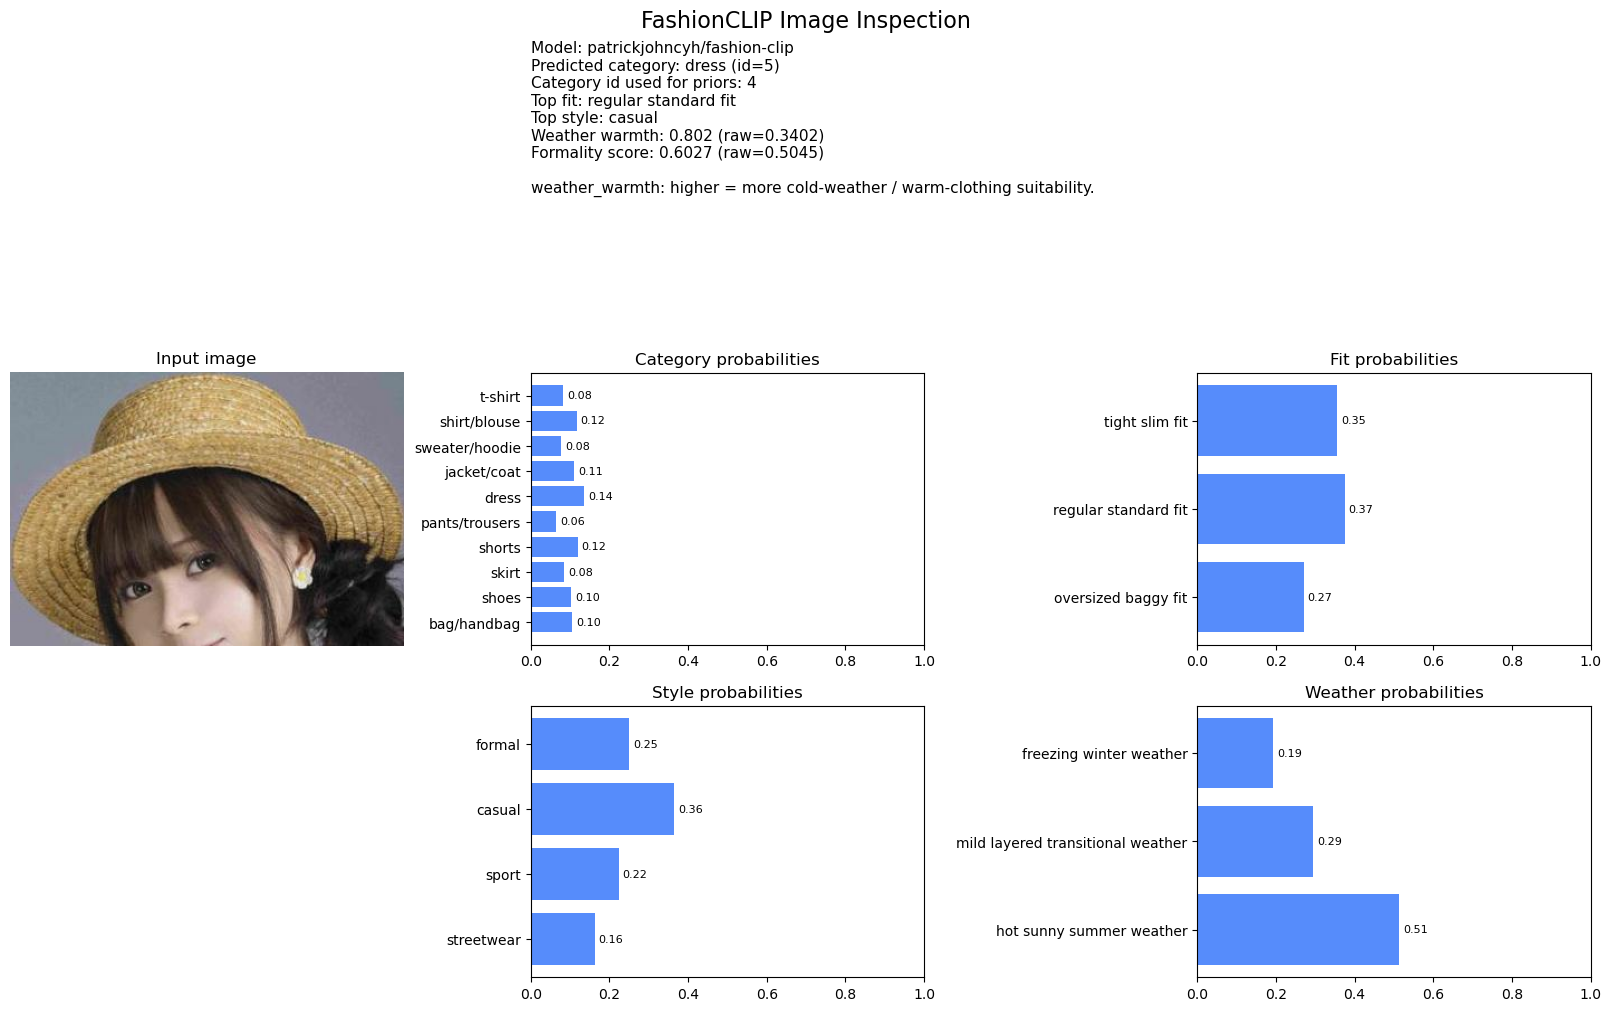

{'image_path': 'manual_labeling_data/1022.jpg',
 'model': 'patrickjohncyh/fashion-clip',
 'predicted_category_id': 5,
 'predicted_category_name': 'dress',
 'category_id_used_for_priors': 4,
 'top_fit': 'regular standard fit',
 'top_style': 'casual',
 'weather_warmth': 0.802,
 'weather_warmth_raw': 0.3402,
 'formality_score': 0.6027,
 'formality_score_raw': 0.5045,
 'category_probs': {'t-shirt': 0.0819,
  'shirt/blouse': 0.1167,
  'sweater/hoodie': 0.0776,
  'jacket/coat': 0.1107,
  'dress': 0.1365,
  'pants/trousers': 0.0647,
  'shorts': 0.1191,
  'skirt': 0.0849,
  'shoes': 0.1031,
  'bag/handbag': 0.1049},
 'fit_probs': {'tight slim fit': 0.3549,
  'regular standard fit': 0.3743,
  'oversized baggy fit': 0.2708},
 'style_probs': {'formal': 0.2498,
  'casual': 0.3641,
  'sport': 0.2232,
  'streetwear': 0.1628},
 'weather_probs': {'freezing winter weather': 0.1932,
  'mild layered transitional weather': 0.2939,
  'hot sunny summer weather': 0.5129},
 'formality_probs': {'formal black t

In [30]:
result = inspect_fashionclip_image(
    image_path="clip_based_data_generation/manual_labeling_data/1022.jpg",
    category_id=4,
    output_path="./my_jacket_report.png",
)

result

In [16]:
"""
1.B — Multi-Attribute Classifier: Dataset Generation FashionCLIP
=====================================================
Generates pseudo-labeled training data for the EfficientNet-B0 multi-head
attribute classifier by running FashionCLIP over Fashionpedia crops.

Pipeline:
    Fashionpedia COCO annotations
        → crop garments
        → FashionCLIP pseudo-label
        → save .pt dataset samples

Important:
    FashionCLIP is used ONLY for pseudo-labeling.
    The saved image tensor uses ImageNet normalization because the student model
    is EfficientNet-B0.

Usage:
    python 1b_dataset_generation.py \
        --img_dir  fashionpedia_coco/train \
        --ann_file fashionpedia_coco/train/_annotations.coco.json \
        --out_dir  attribute_dataset/train \
        --batch_size 64

    python 1b_dataset_generation.py \
        --img_dir  fashionpedia_coco/valid \
        --ann_file fashionpedia_coco/valid/_annotations.coco.json \
        --out_dir  attribute_dataset/valid \
        --batch_size 64
"""

import os
import json
import argparse
from pathlib import Path
from typing import Optional

import torch
import torch.nn.functional as F
from PIL import Image, ImageOps
from tqdm import tqdm
from transformers import CLIPModel, CLIPProcessor
from torchvision import transforms


# ──────────────────────────────────────────────────────────────────────────────
# Config
# ──────────────────────────────────────────────────────────────────────────────

FASHIONCLIP_MODEL = "patrickjohncyh/fashion-clip"

# Lower = sharper probabilities.
TAU = 0.01

# Fashionpedia filtered classes, remapped by your COCO generator to 0..26.
CATEGORY_ID_TO_NAME = {
    0: "shirt, blouse", 1: "top, t-shirt, sweatshirt", 2: "sweater", 3: "cardigan", 4: "jacket", 5: "vest", 6: "pants",
    7: "shorts", 8: "skirt", 9: "coat", 10: "dress", 11: "jumpsuit", 12: "cape", 13: "glasses", 14: "hat",
    15: "headband, head covering, hair accessory", 16: "tie", 17: "glove", 18: "watch", 19: "belt", 20: "leg warmer",
    21: "tights, stockings", 22: "sock", 23: "shoe", 24: "bag, wallet", 25: "scarf", 26: "umbrella",
}

# EfficientNet-B0 expects ImageNet normalization.
STUDENT_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


# ──────────────────────────────────────────────────────────────────────────────
# Prompt Banks
# ──────────────────────────────────────────────────────────────────────────────

WEATHER_PROMPTS = [
    "a fashion garment suitable for cold winter weather, heavy insulated clothing, thick coat, scarf or gloves",
    "a fashion garment suitable for mild transitional weather, layered clothing, light jacket or sweater",
    "a fashion garment suitable for hot summer weather, light breathable clothing, short sleeves or thin fabrics",
]

# Higher weather_warmth = warmer clothing / colder-weather suitability.
WEATHER_WEIGHTS = torch.tensor([1.0, 0.5, 0.0], dtype=torch.float32)

FORMALITY_PROMPTS = [
    "black tie formal evening wear, tuxedo or elegant evening gown",
    "business professional suit or formal office attire",
    "smart business casual outfit, neat and polished",
    "casual everyday clothing, relaxed and comfortable",
    "athletic sportswear or gym training outfit",
]

# Higher formality_score = more formal.
FORMALITY_WEIGHTS = torch.tensor([1.0, 0.75, 0.5, 0.25, 0.0], dtype=torch.float32)

FIT_PROMPTS = [
    "tight slim fit clothing closely fitted to the body",
    "regular fit clothing with standard comfortable cut",
    "oversized baggy loose clothing with wide silhouette",
]

STYLE_PROMPTS = [
    "formal elegant fashion style",
    "casual everyday fashion style",
    "athletic sport activewear style",
    "streetwear urban fashion style",
]


# Optional logical priors for scalar values.
# These are nudges, not hard labels.
CATEGORY_PRIORS = {
    1: {"weather": (0.0, 0.5), "formality": (0.0, 0.6)},   # top, t-shirt, sweatshirt
    2: {"weather": (0.5, 0.9), "formality": (0.1, 0.6)},   # sweater
    3: {"weather": (0.4, 0.8), "formality": (0.2, 0.7)},   # cardigan
    4: {"weather": (0.7, 1.0), "formality": (0.2, 0.8)},   # jacket
    6: {"weather": (0.2, 0.8), "formality": (0.1, 0.8)},   # pants
    7: {"weather": (0.0, 0.4), "formality": (0.0, 0.5)},   # shorts
    9: {"weather": (0.8, 1.0), "formality": (0.3, 0.9)},   # coat
    20: {"weather": (0.5, 1.0), "formality": (0.0, 0.4)},  # leg warmer
    25: {"weather": (0.3, 0.9), "formality": (0.1, 0.7)},  # scarf
    26: {"weather": (0.4, 1.0), "formality": (0.0, 0.6)},  # umbrella
}


# ──────────────────────────────────────────────────────────────────────────────
# Utilities
# ──────────────────────────────────────────────────────────────────────────────

def get_best_device() -> str:
    if torch.cuda.is_available():
        return "cuda"

    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"

    return "cpu"


def apply_category_prior(value: float, category_id: int, key: str) -> float:
    prior = CATEGORY_PRIORS.get(int(category_id))

    if prior is None or key not in prior:
        return float(max(0.0, min(1.0, value)))

    low, high = prior[key]
    adjusted = low + (high - low) * value

    return float(max(0.0, min(1.0, adjusted)))


def xywh_to_xyxy(
    bbox: list[float],
    image_width: int,
    image_height: int,
) -> tuple[int, int, int, int]:
    """
    COCO [x, y, w, h] → clipped [x1, y1, x2, y2].
    """
    x, y, w, h = bbox

    x1 = max(0, int(round(x)))
    y1 = max(0, int(round(y)))
    x2 = min(image_width, int(round(x + w)))
    y2 = min(image_height, int(round(y + h)))

    return x1, y1, x2, y2


# ──────────────────────────────────────────────────────────────────────────────
# FashionCLIP Pseudo-Labeler
# ──────────────────────────────────────────────────────────────────────────────

class CLIPPseudoLabeler:
    """
    Wraps FashionCLIP to produce soft pseudo-labels for clothing attributes.
    All text prompts are encoded once and cached for speed.
    """

    def __init__(
        self,
        model_name: str = FASHIONCLIP_MODEL,
        device: Optional[str] = None,
    ):
        self.device = device or get_best_device()

        print(f"[CLIPPseudoLabeler] Loading {model_name} on {self.device}...")

        self.model_name = model_name
        self.model = CLIPModel.from_pretrained(model_name).to(self.device).eval()
        self.processor = CLIPProcessor.from_pretrained(model_name, use_fast=False)

        self._weather_txt = self._encode_text(WEATHER_PROMPTS)
        self._formality_txt = self._encode_text(FORMALITY_PROMPTS)
        self._fit_txt = self._encode_text(FIT_PROMPTS)
        self._style_txt = self._encode_text(STYLE_PROMPTS)

    @torch.no_grad()
    def _encode_text(self, prompts: list[str]) -> torch.Tensor:
        inputs = self.processor(
            text=prompts,
            return_tensors="pt",
            padding=True,
        ).to(self.device)

        feats = self.model.get_text_features(**inputs)
        return F.normalize(feats, dim=-1)

    @staticmethod
    def _get_probs(
        image_features: torch.Tensor,
        text_features: torch.Tensor,
    ) -> torch.Tensor:
        logits = (image_features @ text_features.T) / TAU
        return logits.softmax(dim=-1)

    @staticmethod
    def _weighted_scalar(
            probs: torch.Tensor,
            weights: torch.Tensor,
    ) -> torch.Tensor:
        """
        Computes a pure continuous expected value. Completely removes the
        hard threshold gate to allow smooth, organic distributions.
        """
        weights = weights.to(probs.device)
        return (probs * weights).sum(dim=-1)

    @torch.no_grad()
    def label_batch(self, pil_images: list[Image.Image]) -> dict[str, torch.Tensor]:
        """
        Parameters
        ----------
        pil_images:
            List of cropped garment PIL images.

        Returns
        -------
        fit:
            (B, 3) soft probs [slim, regular, oversized]

        style:
            (B, 4) soft probs [formal, casual, athletic, streetwear]

        weather_warmth:
            (B,) scalar.
            Higher = warmer clothing / colder-weather suitability.

        formality_score:
            (B,) scalar.
            Higher = more formal.
        """
        inputs = self.processor(
            images=pil_images,
            return_tensors="pt",
        ).to(self.device)

        img_f = self.model.get_image_features(**inputs)
        img_f = F.normalize(img_f, dim=-1)

        weather_probs = self._get_probs(img_f, self._weather_txt)
        formality_probs = self._get_probs(img_f, self._formality_txt)
        fit_probs = self._get_probs(img_f, self._fit_txt)
        style_probs = self._get_probs(img_f, self._style_txt)

        weather_warmth = self._weighted_scalar(weather_probs, WEATHER_WEIGHTS)
        formality_score = self._weighted_scalar(formality_probs, FORMALITY_WEIGHTS)

        return {
            "fit": fit_probs.cpu(),
            "style": style_probs.cpu(),
            "weather_warmth": weather_warmth.cpu(),
            "formality_score": formality_score.cpu(),
            "weather_probs": weather_probs.cpu(),
            "formality_probs": formality_probs.cpu(),
        }


# ──────────────────────────────────────────────────────────────────────────────
# Dataset Builder
# ──────────────────────────────────────────────────────────────────────────────

def build_attribute_dataset(
    img_dir: str,
    ann_file: str,
    out_dir: str,
    batch_size: int = 64,
    clip_model: str = FASHIONCLIP_MODEL,
    min_crop_px: int = 32,
    overwrite: bool = False,
    use_category_priors: bool = True,
) -> None:
    """
    Reads a COCO-format annotation file, crops every annotated garment,
    pseudo-labels it with FashionCLIP, and saves individual sample .pt files.
    """
    img_dir_path = Path(img_dir)
    ann_file_path = Path(ann_file)
    out_dir_path = Path(out_dir)

    out_dir_path.mkdir(parents=True, exist_ok=True)

    with open(ann_file_path, "r", encoding="utf-8") as f:
        coco = json.load(f)

    id2file = {
        int(img["id"]): img["file_name"]
        for img in coco["images"]
    }

    annotations = coco["annotations"]

    labeler = CLIPPseudoLabeler(model_name=clip_model)

    print(f"[build] {len(annotations)} annotations → batch_size={batch_size}")

    batch_crops: list[Image.Image] = []
    batch_meta: list[dict] = []

    skipped = 0
    saved = 0

    def flush_batch() -> None:
        nonlocal saved

        if not batch_crops:
            return

        labels = labeler.label_batch(batch_crops)

        for i, meta in enumerate(batch_meta):
            out_path = out_dir_path / f"{meta['ann_id']}.pt"

            if out_path.exists() and not overwrite:
                continue

            category_id = int(meta["category_id"])

            weather = float(labels["weather_warmth"][i].item())
            formality = float(labels["formality_score"][i].item())

            weather_raw = weather
            formality_raw = formality

            if use_category_priors:
                weather = apply_category_prior(weather, category_id, "weather")
                formality = apply_category_prior(formality, category_id, "formality")

            crop_tensor = STUDENT_TRANSFORM(batch_crops[i])

            sample = {
                "image": crop_tensor,
                "category_id": category_id,
                "category_name": CATEGORY_ID_TO_NAME.get(category_id, str(category_id)),
                "fit": labels["fit"][i].float(),
                "style": labels["style"][i].float(),
                "weather_warmth": weather,
                "formality_score": formality,
                "metadata": {
                    "ann_id": int(meta["ann_id"]),
                    "image_id": int(meta["image_id"]),
                    "file_name": meta["file_name"],
                    "bbox_xywh": [float(v) for v in meta["bbox"]],
                    "weather_warmth_raw": weather_raw,
                    "formality_score_raw": formality_raw,
                    "clip_model": clip_model,
                    "use_category_priors": use_category_priors,
                },
            }

            torch.save(sample, out_path)
            saved += 1

        batch_crops.clear()
        batch_meta.clear()

    for ann in tqdm(annotations, desc="Labeling crops"):
        try:
            image_id = int(ann["image_id"])

            if image_id not in id2file:
                skipped += 1
                continue

            file_name = id2file[image_id]
            img_path = img_dir_path / file_name

            if not img_path.exists():
                skipped += 1
                continue

            img = ImageOps.exif_transpose(Image.open(img_path)).convert("RGB")
            img_w, img_h = img.size

            x1, y1, x2, y2 = xywh_to_xyxy(
                bbox=ann["bbox"],
                image_width=img_w,
                image_height=img_h,
            )

            if (x2 - x1) < min_crop_px or (y2 - y1) < min_crop_px:
                skipped += 1
                continue

            crop = img.crop((x1, y1, x2, y2))

            batch_crops.append(crop)
            batch_meta.append({
                "ann_id": int(ann["id"]),
                "image_id": image_id,
                "file_name": file_name,
                "category_id": int(ann["category_id"]),
                "bbox": ann["bbox"],
            })

            if len(batch_crops) >= batch_size:
                flush_batch()

        except Exception:
            skipped += 1

    flush_batch()

    print(f"[build] Done. Saved {saved} samples | Skipped {skipped}")


# # ──────────────────────────────────────────────────────────────────────────────
# # CLI
# # ──────────────────────────────────────────────────────────────────────────────
#
# if __name__ == "__main__":
#     parser = argparse.ArgumentParser(
#         description="Generate FashionCLIP pseudo-labels for WardrobeGenie 1.B"
#     )
#
#     parser.add_argument("--img_dir", required=True, help="Folder containing split images")
#     parser.add_argument("--ann_file", required=True, help="COCO annotation JSON for the split")
#     parser.add_argument("--out_dir", required=True, help="Where to save .pt sample files")
#
#     parser.add_argument("--batch_size", type=int, default=64)
#     parser.add_argument("--clip_model", default=FASHIONCLIP_MODEL)
#     parser.add_argument("--min_crop_px", type=int, default=32)
#
#     parser.add_argument(
#         "--overwrite",
#         action="store_true",
#         help="Overwrite existing .pt files",
#     )
#
#     parser.add_argument(
#         "--no_category_priors",
#         action="store_true",
#         help="Disable logical category priors for weather/formality scalar labels",
#     )
#
#     args = parser.parse_args()
#
#     build_attribute_dataset(
#         img_dir=args.img_dir,
#         ann_file=args.ann_file,
#         out_dir=args.out_dir,
#         batch_size=args.batch_size,
#         clip_model=args.clip_model,
#         min_crop_px=args.min_crop_px,
#         overwrite=args.overwrite,
#         use_category_priors=not args.no_category_priors,
#     )

In [17]:
import os
import json
import random
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageOps
from tqdm import tqdm

def profile_distribution(img_dir, ann_file, sample_size=300):
    """Loads a random sample of crops and returns a DataFrame of their pseudo-labels."""
    with open(ann_file, "r", encoding="utf-8") as f:
        coco = json.load(f)

    id2file = {img["id"]: img["file_name"] for img in coco["images"]}
    annotations = coco["annotations"]

    random.seed(42)
    # Take a random sample to keep EDA fast
    sampled_anns = random.sample(annotations, min(sample_size, len(annotations)), )
    labeler = CLIPPseudoLabeler()

    records = []
    batch_crops = []
    batch_meta = []

    print(f"Processing a sample of {len(sampled_anns)} garments...")
    for ann in tqdm(sampled_anns):
        image_id = ann["image_id"]
        if image_id not in id2file: continue

        img_path = os.path.join(img_dir, id2file[image_id])
        if not os.path.exists(img_path): continue

        try:
            img = ImageOps.exif_transpose(Image.open(img_path)).convert("RGB")
            x1, y1, x2, y2 = xywh_to_xyxy(ann["bbox"], img.width, img.height)
            if (x2 - x1) < 32 or (y2 - y1) < 32: continue

            batch_crops.append(img.crop((x1, y1, x2, y2)))
            batch_meta.append(ann)
        except Exception:
            continue

    # Run inference on the sampled batch
    if batch_crops:
        labels = labeler.label_batch(batch_crops)

        for i, ann in enumerate(batch_meta):
            cat_id = int(ann["category_id"])
            cat_name = CATEGORY_ID_TO_NAME.get(cat_id, "unknown")

            w_raw = labels["weather_warmth"][i].item()
            f_raw = labels["formality_score"][i].item()

            # Apply priors to see the delta
            w_prior = apply_category_prior(w_raw, cat_id, "weather")
            f_prior = apply_category_prior(f_raw, cat_id, "formality")

            records.append({
                "category": cat_name,
                "weather_raw": w_raw,
                "weather_adjusted": w_prior,
                "formality_raw": f_raw,
                "formality_adjusted": f_prior,
                "fit_slim": labels["fit"][i][0].item(),
                "fit_regular": labels["fit"][i][1].item(),
                "fit_oversized": labels["fit"][i][2].item(),
                "style_formal": labels["style"][i][0].item(),
                "style_casual": labels["style"][i][1].item(),
                "style_athletic": labels["style"][i][2].item(),
                "style_street": labels["style"][i][3].item(),
            })

    return pd.DataFrame(records)

# --- EXECUTE SAMPLE ---
# Adjust these paths to your local setup (validation split is ideal for a quick check)
IMG_DIR = "../../data/fashionpedia_coco/valid"
ANN_FILE = "../../data/fashionpedia_coco/valid/_annotations.coco.json"

df_sample = profile_distribution(IMG_DIR, ANN_FILE, sample_size=300)

[CLIPPseudoLabeler] Loading patrickjohncyh/fashion-clip on mps...


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Processing a sample of 300 garments...


100%|██████████| 300/300 [00:01<00:00, 283.40it/s]


In [20]:
import os
import json
import torch
import pandas as pd
from PIL import Image, ImageOps
from tqdm import tqdm

def profile_full_dataset(img_dir, ann_file, batch_size=64):
    """
    Streams and profiles the entire dataset using batching to prevent OOM errors.
    Returns a complete Pandas DataFrame of all valid crop attributes.
    """
    with open(ann_file, "r", encoding="utf-8") as f:
        coco = json.load(f)

    id2file = {img["id"]: img["file_name"] for img in coco["images"]}
    annotations = coco["annotations"]

    labeler = CLIPPseudoLabeler()
    records = []

    batch_crops = []
    batch_meta = []

    def process_current_batch():
        if not batch_crops:
            return

        # Run FashionCLIP inference on the chunk
        labels = labeler.label_batch(batch_crops)

        for i, ann in enumerate(batch_meta):
            cat_id = int(ann["category_id"])
            cat_name = CATEGORY_ID_TO_NAME.get(cat_id, f"unknown_{cat_id}")

            w_raw = labels["weather_warmth"][i].item()
            f_raw = labels["formality_score"][i].item()

            # Compute adjusted values to evaluate prior impacts
            w_prior = apply_category_prior(w_raw, cat_id, "weather")
            f_prior = apply_category_prior(f_raw, cat_id, "formality")

            records.append({
                "category": cat_name,
                "weather_raw": w_raw,
                "weather_adjusted": w_prior,
                "formality_raw": f_raw,
                "formality_adjusted": f_prior,
                "fit_slim": labels["fit"][i][0].item(),
                "fit_regular": labels["fit"][i][1].item(),
                "fit_oversized": labels["fit"][i][2].item(),
                "style_formal": labels["style"][i][0].item(),
                "style_casual": labels["style"][i][1].item(),
                "style_athletic": labels["style"][i][2].item(),
                "style_street": labels["style"][i][3].item(),
            })

        # Clear lists to free memory
        batch_crops.clear()
        batch_meta.clear()

    print(f"Starting full profiling for {len(annotations)} annotations...")

    for ann in tqdm(annotations, desc="Processing entire dataset"):
        image_id = ann["image_id"]
        if image_id not in id2file:
            continue

        img_path = os.path.join(img_dir, id2file[image_id])
        if not os.path.exists(img_path):
            continue

        try:
            img = ImageOps.exif_transpose(Image.open(img_path)).convert("RGB")
            x1, y1, x2, y2 = xywh_to_xyxy(ann["bbox"], img.width, img.height)

            # Skip invalid/tiny crops
            if (x2 - x1) < 32 or (y2 - y1) < 32:
                continue

            batch_crops.append(img.crop((x1, y1, x2, y2)))
            batch_meta.append(ann)

            # If batch is full, process it immediately
            if len(batch_crops) >= batch_size:
                process_current_batch()

        except Exception as e:
            # Silently catch isolated image corruptions to keep processing going
            continue

    # Flush any remaining items in the final partial batch
    process_current_batch()

    print(f"\nSuccessfully profiled {len(records)} garment crops.")
    return pd.DataFrame(records)

# --- RUN ON WHOLE SPLIT ---
# Using the validation split first is highly recommended as a sanity check
# before executing on the massive training set.
IMG_DIR = "../../data/fashionpedia_coco/valid"
ANN_FILE = "../../data/fashionpedia_coco/valid/_annotations.coco.json"

df_full = profile_full_dataset(IMG_DIR, ANN_FILE, batch_size=64)

[CLIPPseudoLabeler] Loading patrickjohncyh/fashion-clip on mps...


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Starting full profiling for 32693 annotations...


Processing entire dataset: 100%|██████████| 32693/32693 [07:15<00:00, 75.01it/s] 



Successfully profiled 29551 garment crops.


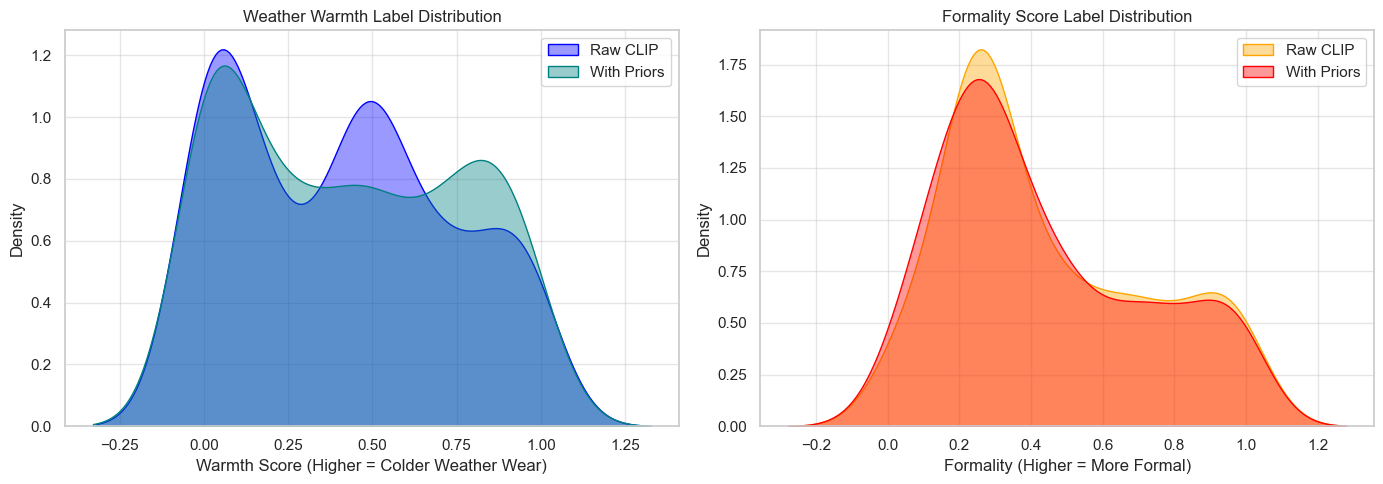

In [21]:
plt.figure(figsize=(14, 5))
sns.set_theme(style="whitegrid")

# Weather Warmth Distribution
plt.subplot(1, 2, 1)
sns.kdeplot(data=df_sample, x="weather_raw", label="Raw CLIP", fill=True, alpha=0.4, color="blue")
sns.kdeplot(data=df_sample, x="weather_adjusted", label="With Priors", fill=True, alpha=0.4, color="teal")
plt.title("Weather Warmth Label Distribution")
plt.xlabel("Warmth Score (Higher = Colder Weather Wear)")
plt.legend()

# Formality Score Distribution
plt.subplot(1, 2, 2)
sns.kdeplot(data=df_sample, x="formality_raw", label="Raw CLIP", fill=True, alpha=0.4, color="orange")
sns.kdeplot(data=df_sample, x="formality_adjusted", label="With Priors", fill=True, alpha=0.4, color="red")
plt.title("Formality Score Label Distribution")
plt.xlabel("Formality (Higher = More Formal)")
plt.legend()

plt.tight_layout()
plt.show()

/var/folders/23/d0f0651j24d9y8lqrqd6k1dw0000gn/T/ipykernel_86907/1837844612.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_fit, x="Fit Attribute", y="Probability", palette="Pastel1")
/var/folders/23/d0f0651j24d9y8lqrqd6k1dw0000gn/T/ipykernel_86907/1837844612.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_style, x="Style Attribute", y="Probability", palette="Pastel2")


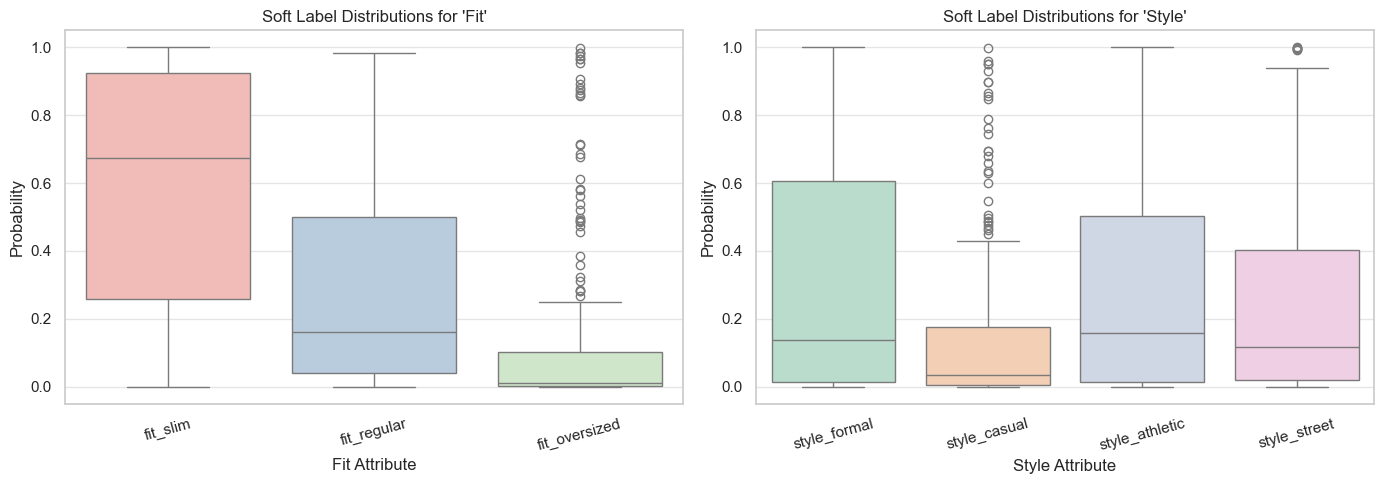

In [22]:
plt.figure(figsize=(14, 5))

# Fit Breakdown
plt.subplot(1, 2, 1)
fit_cols = ["fit_slim", "fit_regular", "fit_oversized"]
df_fit = df_sample[fit_cols].melt(var_name="Fit Attribute", value_name="Probability")
sns.boxplot(data=df_fit, x="Fit Attribute", y="Probability", palette="Pastel1")
plt.title("Soft Label Distributions for 'Fit'")
plt.xticks(rotation=15)

# Style Breakdown
plt.subplot(1, 2, 2)
style_cols = ["style_formal", "style_casual", "style_athletic", "style_street"]
df_style = df_sample[style_cols].melt(var_name="Style Attribute", value_name="Probability")
sns.boxplot(data=df_style, x="Style Attribute", y="Probability", palette="Pastel2")
plt.title("Soft Label Distributions for 'Style'")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()